<a href="https://colab.research.google.com/github/TeraneAgaeva/python_for_ds_tasks/blob/main/Agaeva__%22HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [168]:
pip install --upgrade scikit-learn

In [169]:
import sklearn
print(sklearn.__version__)
print(sklearn.__file__) # Это покажет, откуда загружен пакет

1.7.1
/usr/local/lib/python3.11/dist-packages/sklearn/__init__.py


In [170]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as pl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

**Рішення 1:**

In [171]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [172]:
!ls /content/drive/MyDrive/ML/ML_module_2.2

cars.csv  medical-charges.csv


In [173]:
cars_df = pd.read_csv('/content/drive/MyDrive/ML/ML_module_2.2/cars.csv')

In [174]:
cars_df.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


**Рішення 2:**

In [175]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [176]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [177]:
# Списки для збереження класифікованих колонок
numerical_cols = []
categorical_cols = []
binary_categorical_cols = []
multi_categorical_nominal_cols = []
ordinal_categorical_cols = []

In [178]:
# Пройдемся по всім колонкам
for col in cars_df.columns:
    # Спроба перетворити на числовий тип. Якщо False то це категоріальна.
    # errors='coerce' замінює помилки на NaN, а is_numeric_dtype перевіряє тип  .pd.to_numeric(cars_df['Kilometers_Driven'], errors='coerce'). У нашому випадку errors='coerce' не підходить адже всі категоріальні будуть NaN. Зручно використовувати якщо в полі числові та не числові, а потрібні числові
    if pd.api.types.is_numeric_dtype(cars_df[col]):
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

        # Додатково перевірка для категориальних колонок
        unique_values = cars_df[col].nunique() # Кількість унікальних значень

        if unique_values == 2:
            binary_categorical_cols.append(col)
        elif unique_values > 2:
            # Вручну визначити чи є порядок
            # 'Owner_Type' - схоже що є порядок. 'Transmission' можливо
            # 'Brand', 'Model', 'Fuel_Type', 'Transmission' - номінальні.

            # На основі аналізу вище розподіляємо на ті що мають порядок  ordinal_categorical_cols та ті що не мають порядок multi_categorical_nominal_cols
            if col == 'Owner_Type':
                ordinal_categorical_cols.append(col)
            elif col in ['Brand', 'Model', 'Fuel_Type', 'Transmission']:
                multi_categorical_nominal_cols.append(col)

            else:
                multi_categorical_nominal_cols.append(col) # По замовчуванню вважаємо мультикатегоріальними без порядку


print("--- Аналіз колонок DataFrame ---")
print(f"Кількість колонок: {len(cars_df.columns)}")

print(f"\nЧислові колонки ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"- {col}")

print(f"\nКатегоріальні колонки ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"- {col} (унікальні значення : {cars_df[col].nunique()})")

print(f"\n  Бінарні категоріальні колонки ({len(binary_categorical_cols)}):")
for col in binary_categorical_cols:
    print(f"  - {col} (Значення: {cars_df[col].unique()})")

print(f"\n  Мультикатегоріальні (номінальні, без порядку) колонки ({len(multi_categorical_nominal_cols)}):")
for col in multi_categorical_nominal_cols:
    print(f"  - {col} (Значення: {cars_df[col].unique()})")

print(f"\n  Порядкові категориальні колонки (можна установити порядок) ({len(ordinal_categorical_cols)}):")
for col in ordinal_categorical_cols:
    print(f"  - {col} ( порядок: First < Second < Third)") # визначили порядок вручну

--- Аналіз колонок DataFrame ---
Кількість колонок: 13

Числові колонки (8):
- Car_ID
- Year
- Kilometers_Driven
- Mileage
- Engine
- Power
- Seats
- Price

Категоріальні колонки (5):
- Brand (унікальні значення : 11)
- Model (унікальні значення : 58)
- Fuel_Type (унікальні значення : 2)
- Transmission (унікальні значення : 2)
- Owner_Type (унікальні значення : 3)

  Бінарні категоріальні колонки (2):
  - Fuel_Type (Значення: ['Petrol' 'Diesel'])
  - Transmission (Значення: ['Manual' 'Automatic'])

  Мультикатегоріальні (номінальні, без порядку) колонки (2):
  - Brand (Значення: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes'])
  - Model (Значення: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'W

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

**Рішення 3:**

In [179]:
# Визначаємо вхідні дані і таргет
inputs, targets = cars_df.drop(['Price'], axis = 1), cars_df['Price']  # для inputs(незалежні змінні) - всі поля крім цільвої залежної змінної Price

In [180]:
# Розділяємо дані на тренувальні і тест
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

**Рішення 4.1.:**

In [181]:
cars_df['Fuel_Type'].unique()

array(['Petrol', 'Diesel'], dtype=object)

In [182]:
cars_df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [183]:
# 4.1. Кодування колонок з бінарним значенням.
Fuel_Type_codes = {'Diesel': 0, 'Petrol': 1}   # Petrol більше значень тому 1
cars_df['Fuel_Type_code'] = cars_df.Fuel_Type.map(Fuel_Type_codes) # додаємо нове поле


In [184]:
cars_df.Price.corr(cars_df.Fuel_Type_code)

np.float64(-0.18096358734385454)

In [185]:
cars_df['Transmission'].value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [186]:
counts = cars_df['Transmission'].value_counts()

In [187]:
if counts['Automatic'] > counts['Manual']:
    Transmission_codes = {'Manual': 0, 'Automatic': 1}
else:
    Transmission_codes = {'Manual': 1, 'Automatic': 0}

print("\nАвтоматично визначили Transmission_codes:", Transmission_codes)


Автоматично визначили Transmission_codes: {'Manual': 0, 'Automatic': 1}


In [188]:
cars_df['Transmission_code'] = cars_df.Transmission.map(Transmission_codes) # додаємо нове поле

In [189]:
cars_df.Price.corr(cars_df.Transmission_code)

np.float64(0.6764835122739136)

**Висновок 4.1.:** Кореляція ціни авто від палива зворотня та дуже низька -0,18, тобто якщо паливо буде бензин то ціна буде трохи дешевша. Кореляція ціни авто та автомат/механіка має високу кореляцію 0,67 - ціна збільшується коли коробка передач автомат

**Рішення 4.2.:**

In [190]:
# 4.2. Закодуємо колонку Brand з використанням sklearn.preprocessing.OneHotEncoder

cars_df['Brand'].unique()

array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

In [191]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# навчаєм (fit) Encoder Тільки на тренувальних даних
enc.fit(inputs_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [192]:
one_hot_tr = enc.transform(inputs_train[['Brand']])
one_hot_tr

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.

In [193]:
one_hot_test = enc.transform(inputs_test[['Brand']])
one_hot_test

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.

In [194]:
enc.categories_[0]

array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
       'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)

In [195]:
inputs_train

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4
6,7,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,140,7
27,28,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,187,5


In [196]:
inputs_train[enc.categories_[0]] = one_hot_tr # включаємо нові стовпці модеделй авто до нашої моделі лінійної регресії. Це прокодовані категоріальні

In [197]:
inputs_test[enc.categories_[0]] = one_hot_test # включаємо нові стовпці модеделй авто до нашої моделі лінійної регресії. Це прокодовані категоріальні

In [198]:
inputs_train.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [199]:
inputs_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 83 to 75
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Car_ID             80 non-null     int64  
 1   Brand              80 non-null     object 
 2   Model              80 non-null     object 
 3   Year               80 non-null     int64  
 4   Kilometers_Driven  80 non-null     int64  
 5   Fuel_Type          80 non-null     object 
 6   Transmission       80 non-null     object 
 7   Owner_Type         80 non-null     object 
 8   Mileage            80 non-null     int64  
 9   Engine             80 non-null     int64  
 10  Power              80 non-null     int64  
 11  Seats              80 non-null     int64  
 12  Audi               80 non-null     float64
 13  BMW                80 non-null     float64
 14  Ford               80 non-null     float64
 15  Honda              80 non-null     float64
 16  Hyundai            80 non-null  

In [200]:
inputs_test.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [201]:
inputs_test.columns

Index(['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
       'Mercedes', 'Tata', 'Toyota', 'Volkswagen'],
      dtype='object')

In [202]:
# нові стовпці модеделй авто у списку
enc.categories_[0].tolist()

['Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen']

In [203]:
categorial_code = enc.categories_[0].tolist()

In [204]:
input_cols_train_ = inputs_train.columns.tolist() # перелік полів після додавання enc.categories_
input_cols_train_

['Car_ID',
 'Brand',
 'Model',
 'Year',
 'Kilometers_Driven',
 'Fuel_Type',
 'Transmission',
 'Owner_Type',
 'Mileage',
 'Engine',
 'Power',
 'Seats',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen']

In [205]:
input_cols_test_ = inputs_test.columns.tolist()
input_cols_test_

['Car_ID',
 'Brand',
 'Model',
 'Year',
 'Kilometers_Driven',
 'Fuel_Type',
 'Transmission',
 'Owner_Type',
 'Mileage',
 'Engine',
 'Power',
 'Seats',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen']

In [206]:
# перевіримо чи є різниця в наборах полів
diff1_not_in_2 = list(set(input_cols_train_) - set(input_cols_test_))
diff1_not_in_2

[]

In [207]:
diff2_not_in_1 = list(set(input_cols_test_) - set(input_cols_train_))
diff2_not_in_1

[]

In [208]:
# залишаємо тільки числові дані, адже лінійна регресія не працює з полями категоріальними
inputs_train_2 = inputs_train.select_dtypes(include=np.number)

In [209]:
inputs_test_2 = inputs_test.select_dtypes(include=np.number)

In [210]:
model = LinearRegression().fit(inputs_train_2, targets_train) # LinearRegression() создает новый, пустой объект модели линейной регрессии из библиотеки scikit-learn. .fit(inputs, targets) является ключевым шагом. Он обучает эту модель, используя предоставленные данные
predictions_train = model.predict(inputs_train_2) #  считает предсказанные значения целевой переменной (price) на основе входных данных (inputs) с помощью уже обученной модели (model).
predictions_test = model.predict(inputs_test_2)
loss_train = np.sqrt(mean_squared_error(targets_train, predictions_train)) #RMSE (корень из среднеквадратичной ошибки) между фактическими (targets) и предсказанными (predictions) значениями
loss_test = np.sqrt(mean_squared_error(targets_test, predictions_test))

print('loss_train:', loss_train, 'loss_test:', loss_test)

loss_train: 254804.7643031979 loss_test: 247202.8481612591


In [211]:
# пепевірка іншим способом розрахунку
loss_train_check = root_mean_squared_error(targets_train, predictions_train)
loss_test_check = root_mean_squared_error(targets_test, predictions_test)
print('loss_train_check:', loss_train_check, 'loss_test_check:', loss_test_check)

loss_train_check: 254804.7643031979 loss_test_check: 247202.8481612591


In [212]:
#функція

def train_model_show_rmse(inputs_train, targets_train, inputs_test, targets_test):
  model = LinearRegression().fit(inputs_train, targets_train) # LinearRegression() создает новый, пустой объект модели линейной регрессии из библиотеки scikit-learn. .fit(inputs, targets) является ключевым шагом. Он обучает эту модель, используя предоставленные данные
  predictions_tr = model.predict(inputs_train) #  считает предсказанные значения целевой переменной (charges) на основе входных данных (inputs) с помощью уже обученной модели (model).
  predictions_tst = model.predict(inputs_test)
  loss_tr = root_mean_squared_error(targets_train, predictions_tr) #RMSE (корень из среднеквадратичной ошибки) между фактическими (targets) и предсказанными (predictions) значениями
  loss_tst = root_mean_squared_error(targets_test, predictions_tst)
  print('loss_tr:', loss_tr,'loss_tst:', loss_tst)
  return model

In [213]:
# розрахунок через функцію
model_test = train_model_show_rmse(inputs_train_2, targets_train, inputs_test_2, targets_test)

loss_tr: 254804.7643031979 loss_tst: 247202.8481612591


In [214]:
print('min:', cars_df.Price.min(), 'max:', cars_df.Price.max(), 'mean:', cars_df.Price.mean(), 'std:', cars_df.Price.std())


min: 450000 max: 4000000 mean: 1574000.0 std: 1000264.6114550354


**Висновок 4.2.**: Ми бачимо, що помилка на тестових даних меньша ніж на тренувальних 248 та 255 тис відповідно. Зменшення помилки говорить про правильність роботи моделі. Проте на перший погляд відхилення в ціні на 248-255 тис виглядає досить суттєвим і було б краще пошукати ще моделі для зменшення цієї помилки. Проте якщо помилку порівняти з фактичними данними такими як мінімум, максимум, середнє та стандартне відхилення, то бачимо що помилка прогнозу за моделлю не перевищує жодного з фактичних показників, то начеб то можна вважати допустимим відхиленням.

Колонку Owner_Type з використанням sklearn.preprocessing.OrdinalEncoder я закодую для вас. Проаналізуйте, що відбувається.

Колонка Model містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

**Рішення 4.3.:**

In [215]:
# 4.3. Колонка Owner_Type закодована з використанням sklearn.preprocessing.OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(inputs_train[['Owner_Type']])

inputs_train['Owner_Type_Codes'] = ordenc.transform(inputs_train[['Owner_Type']])
inputs_test['Owner_Type_Codes'] = ordenc.transform(inputs_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [216]:
pd.set_option('display.max_columns', 100)
display(inputs_train.head()), display(inputs_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Висновок 4.3.:** Для поля Owner_Type створено колонку Owner_Type_Codes, в якій визначено порядок шляхом нумерації послідовності. Перший - 0, другий - 1 і так далі.

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

**Рішення 5:**

In [217]:
#inputs_train_2 вже не містить категоріальних даних, видалено у завданні 4.2
inputs_train_2

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,2019,22000,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,2018,28000,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,2018,28000,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,2017,32000,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,2017,26000,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,2017,20000,10,4951,395,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,2018,45000,15,2179,140,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
27,28,2019,22000,18,1995,187,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [218]:
inputs_train_2.select_dtypes(include=np.number) # перевіряємо

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,2019,22000,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,2018,28000,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,2018,28000,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,2017,32000,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,2017,26000,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,2017,20000,10,4951,395,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,2018,45000,15,2179,140,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
27,28,2019,22000,18,1995,187,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [219]:
#об'єднуємо inputs_train_2, targets_train

train_df = pd.concat([inputs_train_2, targets_train], axis=1)
train_df

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Price
83,84,2019,22000,18,1498,148,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1600000
55,56,2018,28000,17,1968,187,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2600000
26,27,2018,28000,15,1984,241,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3200000
54,55,2017,32000,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,650000
19,20,2017,26000,12,1991,241,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,2020,30000,23,1248,74,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,600000
2,3,2017,20000,10,4951,395,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500000
6,7,2018,45000,15,2179,140,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,900000
27,28,2019,22000,18,1995,187,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2800000


<Axes: >

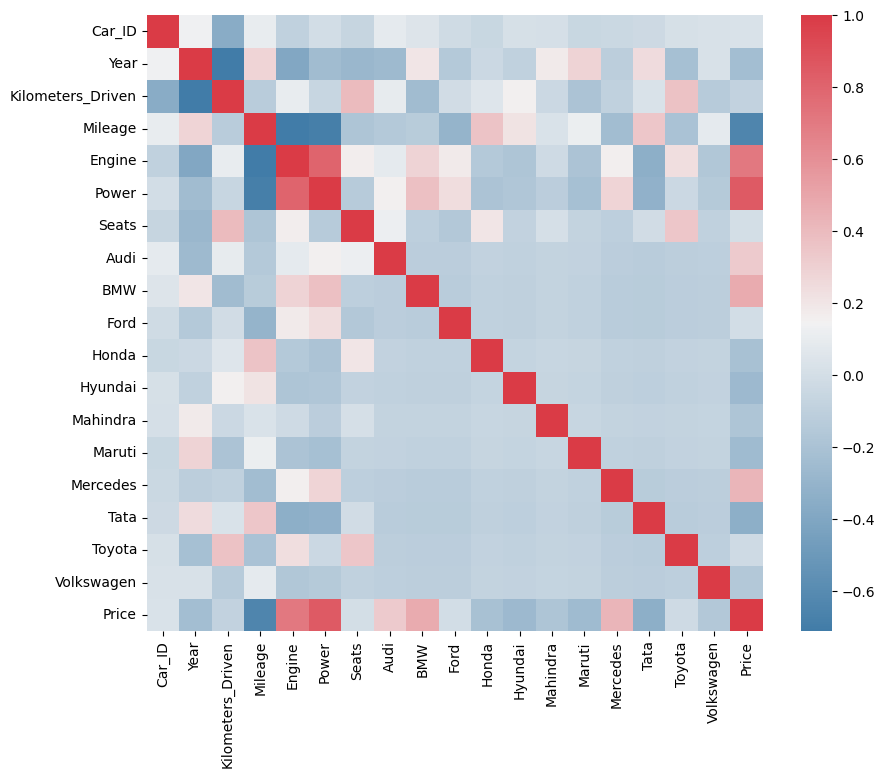

In [220]:
# Побудуємо матрицю корреляції

f, ax = pl.subplots(figsize=(10, 8))
corr = train_df.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(240,10,as_cmap=True),
            square=True, ax=ax)

**Висновок 5:**

Графік матриці кореляції показує взаємозв'язок між усіма парами змінних. Колір та інтенсивність відображають силу та напрямок кореляції: червоний – сильна позитивна, синій – сильна негативна, світліші відтінки – слабша кореляція.

Колонки, які корелюють з цільовою змінною Price на більш ніж 0.5 за модулем, є:

  Year: Сильна позитивна кореляція (інтенсивний червоний колір). Це означає, що новіші автомобілі (більший Year), як правило, дорожчі.

  Engine: Сильна позитивна кореляція (інтенсивний червоний колір). Більший об'єм двигуна або потужність (більший Engine) пов'язані з вищою ціною.

  Power: Сильна позитивна кореляція (інтенсивний червоний колір). Більша потужність, як правило, вказує на вищу ціну.

  Mercedes: Сильна позитивна кореляція (інтенсивний червоний колір). Автомобілі марки Mercedes значно дорожчі.

  BMW: Сильна позитивна кореляція (інтенсивний червоний колір). Автомобілі марки BMW значно дорожчі.

  Audi: Сильна позитивна кореляція (інтенсивний червоний колір). Автомобілі марки Audi значно дорожчі.



Додаткові спостереження:

  Kilometers_Driven та Mileage мають помірну негативну кореляцію з Price (відтінки синього), що очікувано, оскільки збільшення пробігу зазвичай знижує ціну автомобіля.

  Інші бренди, такі як Toyota, Volkswagen, Ford, Honda та інші, мають слабшу або негативну кореляцію з Price, що вказує на їхню нижчу цінову категорію порівняно з преміальними брендами.

Висновок:

Найбільш значущими факторами, що впливають на ціну автомобіля в даному наборі даних, є рік випуску, розмір/потужність двигуна, а також преміальні бренди, такі як Mercedes, BMW та Audi, що мають сильну позитивну кореляцію з ціною.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

**Рішення 6:**

Пункти 0-2 виконані у завданні 4.2.

In [221]:
predictions_train

array([1281110.80036026, 2530296.26773691, 2847915.80121432,
        972758.96536908, 2931206.77225435, 2682496.57694958,
       3211631.16554359,  642151.10691489, 2185655.43429181,
        720424.2899222 ,  744727.93653537, 2604537.26087499,
       3223881.83115032,  635266.40449239, 2633330.78193207,
       1890810.09838402, 3832911.83318356, 1125787.10016059,
       1293971.36771482, 1306222.03332156, 1871428.84680066,
       2588554.23613647, 2613382.22259894, 1855009.71254198,
       2694747.24255632,  722657.77109282,  823530.99639618,
        687724.91524623,  451854.93707582,  403410.55901314,
       3617719.1543553 , 2625632.88820566, 2860166.46682106,
        654401.77252162,  481866.77924101,  708173.62431546,
       1473966.23362999, 3211005.99319413,  900459.51500556,
        732477.27092864, 1023631.13949637, 3629969.81996204,
        739925.53332927, 1195895.78442122, 3059104.49727732,
       1440104.0533624 , 3071355.16288406,  948329.09884413,
        758156.92427357,

In [222]:
targets_train

,Price
83,1600000
55,2600000
26,3200000
54,650000
19,2500000
...,...
3,600000
2,2500000
6,900000
27,2800000


predictions_train та targets_train мають різну структуру. predictions_train  потрібно перетворити в DataFrame

In [223]:
# ТРЕНУВАЛЬНІ ДАНІ
# 1. Перетворити predictions_train (масив NumPy) в Pandas Series.
#    Важливо: використати індекс з targets_train для правильного співставлення.
predictions_train_series = pd.Series(predictions_train, index=targets_train.index)

# 2. Об'єднатив прогнозні та фактичні дані в  один DataFrame для Plotly Express.
plot_df = pd.DataFrame({
    'Actual Price': targets_train,
    'Predicted Price': predictions_train_series
})

# 3. Побудова діаграми розсіювання.
fig = px.scatter(plot_df, x='Actual Price', y='Predicted Price',
                 title='Тренувальні дані: Фактична ціна авто vs. Прогнозована ціна авто',
                 labels={'Actual Price': 'Фактична ціна', 'Predicted Price': 'Прогнозована ціна'})

# 4. Додамо лінію ідельного співпадіння (де Actual == Predicted)
fig.add_shape(type="line", x0=plot_df['Actual Price'].min(), y0=plot_df['Actual Price'].min(),
              x1=plot_df['Actual Price'].max(), y1=plot_df['Actual Price'].max(),
              line=dict(color="Red", width=2, dash="dash"),
              name="Ideal Fit")

fig.update_traces(marker_size=5)
fig.show()

In [224]:
# ТЕСТУВАЛЬНІ ДАНІ
# 1. Перетворити predictions_test (масив NumPy) в Pandas Series.
#    Важливо: використати індекс з targets_train для правильного співставлення.
predictions_test_series = pd.Series(predictions_test, index=targets_test.index)

# 2. Об'єднатив прогнозні та фактичні дані в  один DataFrame для Plotly Express.
plot_df = pd.DataFrame({
    'Actual Price': targets_test,
    'Predicted Price': predictions_test_series
})

# 3. Побудова діаграми розсіювання.
fig = px.scatter(plot_df, x='Actual Price', y='Predicted Price',
                 title='Тестові дані: Фактична ціна авто vs. Прогнозована ціна авто',
                 labels={'Actual Price': 'Фактична ціна', 'Predicted Price': 'Прогнозована ціна'})

# 4. Додамо лінію ідельного співпадіння (де Actual == Predicted)
fig.add_shape(type="line", x0=plot_df['Actual Price'].min(), y0=plot_df['Actual Price'].min(),
              x1=plot_df['Actual Price'].max(), y1=plot_df['Actual Price'].max(),
              line=dict(color="Red", width=2, dash="dash"),
              name="Ideal Fit")

fig.update_traces(marker_size=5)
fig.show()

**Висновок 6:**

Продуктивність моделі тренувальних даних:
Більшість точок на графіку розташовані близько до червоної пунктирної лінії, що вказує на хорошу загальну продуктивність моделі. Модель досить точно прогнозує ціни автомобілів.
Точки, що знаходяться вище червоної лінії, відповідають випадкам, коли модель переоцінила фактичну ціну (прогноз вищий за факт).
Точки, що знаходяться нижче червоної лінії, відповідають випадкам, коли модель недооцінила фактичну ціну (прогноз нижчий за факт).
Розкид точок збільшується зі зростанням ціни, що означає, що для дорожчих автомобілів прогнози моделі стають менш точними, мають більший розкид помилок (можна побачити, що точки далі від лінії при великих значеннях Price). Це звичайне явище в моделях регресії, де абсолютна помилка часто збільшується зі збільшенням цільової змінної.
В цілому, модель демонструє хороші здібності до прогнозування, але є місце для покращення, особливо щодо прогнозування цін на дорожчі автомобілі.



Порівняння результатів роботи моделі на тренувальних даних та тестових:
Те, що модель показує хорошу продуктивність як на тренувальних, так і на тестових даних, вказує на те, що модель не перенавчилася (не "запам'ятала" тренувальні дані надто специфічно). Якби на тестових даних точки були сильно розкидані або далеко від лінії, це було б ознакою перенавчання.
Незначне зниження точності на тесті: Невелике збільшення розкиду на тестових даних, особливо у верхній частині діапазону, є нормальним та очікуваним. Модель завжди працюватиме трохи гірше на даних, яких вона раніше не бачила.
Підтвердження узагальнюючої здатності: Основне завдання тестування моделі — переконатися, що вона добре узагальнює на нові, невидимі дані. Обидва графіки показують, що модель справляється з цим завданням.
Таким чином, графіки загалом схожі за своєю основною тенденцією (точки відповідають лінії ідеального співпадіння), що є хорошою ознакою. Відмінності в щільності та невелике збільшення розкиду на тестових даних є природними.


**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цільову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

**Рішення 7.1.:**

In [225]:
# Маштабувати можна тільки числові колонки. Тому для цього рішення використаємо дані з завдання 4.2: inputs_train_2, targets_train, inputs_test_2, targets_test

In [226]:
scaler = StandardScaler()
scaled_inputs_train= scaler.fit_transform(inputs_train_2) # scaled_inputs_train став Numpy а був inputs_train_2 DataFrame, аналогічно і тестові дані.
scaled_inputs_test = scaler.transform(inputs_test_2) # для test тільки transform

In [227]:
scaled_inputs_train   # scaled_inputs_train став Numpy

array([[ 1.09092769,  0.56881254, -0.69387081, ..., -0.37796447,
        -0.33333333,  3.22932987],
       [ 0.10038127, -0.32344242, -0.03953291, ..., -0.37796447,
        -0.33333333, -0.30966177],
       [-0.92554181, -0.32344242, -0.03953291, ..., -0.37796447,
        -0.33333333, -0.30966177],
       ...,
       [-1.63307497, -0.32344242,  1.81442446, ..., -0.37796447,
        -0.33333333, -0.30966177],
       [-0.89016515,  0.56881254, -0.69387081, ..., -0.37796447,
        -0.33333333, -0.30966177],
       [ 0.80791442,  0.56881254, -0.69387081, ..., -0.37796447,
        -0.33333333, -0.30966177]])

In [228]:
scaled_inputs_test # scaled_inputs_test став Numpy

array([[-1.24393173, -2.10795235,  1.05103025, -0.60469588, -0.78533317,
        -0.23196684, -0.30356247,  3.        , -0.3560345 , -0.3560345 ,
        -0.25819889, -0.2847474 , -0.22941573, -0.25819889, -0.3560345 ,
        -0.37796447, -0.33333333, -0.30966177],
       [-0.39489194,  0.56881254, -0.25764555,  0.86123353, -1.25585925,
        -1.21448688, -0.30356247, -0.33333333, -0.3560345 , -0.3560345 ,
        -0.25819889,  3.51188458, -0.22941573, -0.25819889, -0.3560345 ,
        -0.37796447, -0.33333333, -0.30966177],
       [ 1.40931761, -1.21569739,  0.39669235,  0.27486176, -0.47621732,
        -0.78463436, -0.30356247, -0.33333333, -0.3560345 , -0.3560345 ,
        -0.25819889, -0.2847474 , -0.22941573, -0.25819889, -0.3560345 ,
        -0.37796447, -0.33333333,  3.22932987],
       [-1.35006171,  1.4610675 , -1.13009608,  0.56804765, -0.68330971,
        -0.78463436,  2.39477056, -0.33333333, -0.3560345 , -0.3560345 ,
        -0.25819889, -0.2847474 , -0.22941573,  3.872

In [229]:
# !!! Знову перетворимо  Numpy в DataFrame,
# !!! використовуємо ВХІДНІ НАЗВИ КОЛОНОК
scaled_inputs_train_df = pd.DataFrame(scaled_inputs_train, columns=inputs_train_2.columns, index=inputs_train_2.index)
scaled_inputs_test_df = pd.DataFrame(scaled_inputs_test, columns=inputs_test_2.columns, index=inputs_test_2.index)

In [230]:
# розрахунок через функцію, що прописали у завданні 4.2
model_test_7 = train_model_show_rmse(scaled_inputs_train, targets_train, scaled_inputs_test, targets_test)

loss_tr: 254804.76430319715 loss_tst: 247202.84816124776


**Висновок 7.1.:**

Результати роботи моделі з завдання 4.2:
loss_tr: 254804.76430319645 loss_tst: 247202.8481612472. Бачимо, що стандартизація (масштабування) в завданні 7.1 не вплинула на результати роботи моделі.

**Рішення 7.2.:**

In [231]:
# Визначаємо найважливіші найвпливовіші коефіцієнти
weights_df = pd.DataFrame({
    'feature': np.append(scaled_inputs_train_df.columns.tolist(), 1),
    'weight': np.append(model.coef_, model.intercept_).round(2)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
14,Mercedes,932192.81
8,BMW,882095.06
7,Audi,836570.78
6,Seats,95706.83
1,Year,32642.05
5,Power,5723.75
0,Car_ID,322.39
4,Engine,169.52
2,Kilometers_Driven,0.69
3,Mileage,-7586.94


In [232]:
# Визначаємо найважливіші найвпливовіші коефіцієнти
weights_test_df = pd.DataFrame({
    'feature': np.append(scaled_inputs_test_df.columns.tolist() , 1),
    'weight': np.append(model.coef_, model.intercept_).round(2)
})
weights_test_df.sort_values('weight', ascending=False)

,feature,weight
14,Mercedes,932192.81
8,BMW,882095.06
7,Audi,836570.78
6,Seats,95706.83
1,Year,32642.05
5,Power,5723.75
0,Car_ID,322.39
4,Engine,169.52
2,Kilometers_Driven,0.69
3,Mileage,-7586.94


**Висновок 7.2.:**
Мають найбільший вплив на збільшення ціни:
Mercedes 	932192.81
BMW 	882095.06
Audi 	836570.78
Це часто дорогі авто преміум класу, тому виглядає логічно. Проте ми розуміємо, щоб дати оцінку більш точну потрібно проаналізувати чи в таблицю потрапили саме нові авто - тоді так - логічно.
Найбільший вплив на зниження ціни має 1 вільний член, Hyundai, Mahindra. Але в тих що впливають на зниження ціни є, наприклад, Volkswagen та Toyota, що теж потребує додаткового аналізу

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [233]:
# --- 1. Додамо константу для вільного члена (intercept) до тренувальних даних ---

X_train_sm = sm.add_constant(scaled_inputs_train_df)
y_train = targets_train
# --- 2. Створення та навчання моделі OLS на тренувальних даних ---
# Передамо y_train як залежну змінну, X_train_sm як незалежну змінну
model_sm = sm.OLS(y_train, X_train_sm)
results_sm = model_sm.fit()

# --- 3. Виведемо параметри моделі ---
# results.params будуть включати коефіцієнти, отримані на X_train
print("Параметри моделі (коефіцієнти, навчені на тренувальних даних):")
print(results_sm.params)

# -- 4. Оцінка моделі на тесових даних---

X_test_sm = sm.add_constant(scaled_inputs_test_df) # додаємо константу для вільного члена
y_test = targets_test
predictions_test_sm = results_sm.predict(X_test_sm)

print("\nПередбачення на тестових даних (перші 5):")
print(predictions_test_sm[:5])


print("\nПовні зведені дані результатів навчання моделі :")
print(results_sm.summary())

Параметри моделі (коефіцієнти, навчені на тренувальних даних):
const                1.680000e+06
Car_ID               9.112956e+03
Year                 3.658377e+04
Kilometers_Driven    6.325794e+03
Mileage             -2.587756e+04
Engine               1.113232e+05
Power                4.660466e+05
Seats                7.093775e+04
Audi                 2.291113e+05
BMW                  2.557006e+05
Ford                -1.115335e+05
Honda               -1.051915e+05
Hyundai             -1.445440e+05
Mahindra            -1.251707e+05
Maruti              -1.240334e+05
Mercedes             2.715305e+05
Tata                -1.440507e+05
Toyota              -4.879413e+04
Volkswagen          -6.005236e+04
dtype: float64

Передбачення на тестових даних (перші 5):
17    2.154475e+06
41    3.911599e+05
92    9.850096e+05
14    9.090244e+05
68    7.627941e+05
dtype: float64

Повні зведені дані результатів навчання моделі :
                            OLS Regression Results                       

**Висновок 8:**

In [234]:
 # Аналіз p-value:

# Визначаємо рівень значущості
alpha = 0.05

# Отримуємо таблицю з параметрами (для програмного доступу)
p_values = results_sm.pvalues

print(f"\nСтатистично значущі ознаки на рівні {alpha}:")
significant_features = []
for feature, p_value in p_values.items():
    if p_value < alpha:
        significant_features.append(feature)
        print(f"- {feature} (p-value: {p_value:.4f})")

if not significant_features:
    print("Немає статистично значущих ознак на заданому рівні значущості.")




Статистично значущі ознаки на рівні 0.05:
- const (p-value: 0.0000)
- Power (p-value: 0.0000)
- Audi (p-value: 0.0000)
- BMW (p-value: 0.0000)
- Ford (p-value: 0.0019)
- Honda (p-value: 0.0057)
- Hyundai (p-value: 0.0000)
- Mahindra (p-value: 0.0004)
- Maruti (p-value: 0.0004)
- Mercedes (p-value: 0.0000)
- Tata (p-value: 0.0001)


В завданні 7.1 по маштабованим даним отримали такий результат по моделі:


loss_tr: 254804.76430319715 loss_tst: 247202.84816124776


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [235]:
significant_features_without_const = [f for f in significant_features if f != 'const']
significant_features_without_const


['Power',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata']

In [236]:
scaled_inputs_train_significant_df = scaled_inputs_train_df[significant_features_without_const]
scaled_inputs_test_significant_df = scaled_inputs_test_df[significant_features_without_const]

In [237]:
model_test_9 = train_model_show_rmse(scaled_inputs_train_significant_df , targets_train, scaled_inputs_test_significant_df, targets_test)

loss_tr: 279922.32948844944 loss_tst: 261554.09666814096


В завданні 7.1 по маштабованим даним отримали такий результат по моделі:

loss_tr: 254804.76430319715 loss_tst: 247202.84816124776


In [240]:
# --- 1. Додамо константу для вільного члена (intercept) до тренувальних даних ---

X_train_sm_significant = sm.add_constant(scaled_inputs_train_significant_df)
y_train = targets_train
# --- 2. Створення та навчання моделі OLS на тренувальних даних ---
# Передамо y_train як залежну змінну, X_train_sm як незалежну змінну
model_sm_2 = sm.OLS(y_train, X_train_sm_significant)
results_sm_2 = model_sm_2.fit()

# --- 3. Виведемо параметри моделі ---
# results.params будуть включати коефіцієнти, отримані на X_train
print("Параметри моделі (коефіцієнти, навчені на тренувальних даних):")
print(results_sm_2.params)

# -- 4. Оцінка моделі на тесових даних---

X_test_sm_significant = sm.add_constant(scaled_inputs_test_significant_df) # додаємо константу для вільного члена
y_test = targets_test
predictions_traint_sm_2 = results_sm_2.predict(X_train_sm_significant)
predictions_test_sm_2 = results_sm_2.predict(X_test_sm_significant)


print("\nПовні зведені дані результатів навчання моделі :")
print(results_sm_2.summary())

Параметри моделі (коефіцієнти, навчені на тренувальних даних):
const       1.680000e+06
Power       5.629605e+05
Audi        2.637107e+05
BMW         2.912408e+05
Ford       -8.510584e+04
Honda      -7.201700e+04
Hyundai    -1.297776e+05
Mahindra   -8.524170e+04
Maruti     -9.534960e+04
Mercedes    2.949886e+05
Tata       -1.119768e+05
dtype: float64

Повні зведені дані результатів навчання моделі :
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     87.23
Date:                Thu, 31 Jul 2025   Prob (F-statistic):           4.08e-35
Time:                        11:25:59   Log-Likelihood:                -1116.9
No. Observations:                  80   AIC:                             2256.
Df Residuals:                      69   BIC:

In [241]:
# --- показники R-squared та Adj. R-squared з завдання 8 та з завдання 9---

# Дані з завдання 8:
r_squared_model = results_sm.rsquared
adj_r_squared_model = results_sm.rsquared_adj

print(f"\nМодель завдання 8 (всі ознаки):")
print(f"  R-squared: {r_squared_model:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model:.4f}")

# Дані з завдання 9:
r_squared_model_2 = results_sm_2.rsquared
adj_r_squared_model_2 = results_sm_2.rsquared_adj

print(f"\nМодель завдання 9 (тільки суттєві ознаки):")
print(f"  R-squared: {r_squared_model_2:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model_2:.4f}")


Модель завдання 8 (всі ознаки):
  R-squared: 0.9393
  Adj. R-squared: 0.9226

Модель завдання 9 (тільки суттєві ознаки):
  R-squared: 0.9267
  Adj. R-squared: 0.9161


In [ ]:
scaled_inputs_train_significant_df = scaled_inputs_train_df[significant_features_without_const]
scaled_inputs_test_significant_df = scaled_inputs_test_df[significant_features_without_const]

In [ ]:
model_test_9 = train_model_show_rmse(scaled_inputs_train_significant_df , targets_train, scaled_inputs_test_significant_df, targets_test)

loss_tr: 279922.32948844944 loss_tst: 261554.09666814096


В завданні 7.1 по маштабованим даним отримали такий результат по моделі:

loss_tr: 254804.76430319715 loss_tst: 247202.84816124776


In [ ]:
# --- 1. Додамо константу для вільного члена (intercept) до тренувальних даних ---

X_train_sm_significant = sm.add_constant(scaled_inputs_train_significant_df)
y_train = targets_train
# --- 2. Створення та навчання моделі OLS на тренувальних даних ---
# Передамо y_train як залежну змінну, X_train_sm як незалежну змінну
model_sm_2 = sm.OLS(y_train, X_train_sm_significant)
results_sm_2 = model_sm_2.fit()

# --- 3. Виведемо параметри моделі ---
# results.params будуть включати коефіцієнти, отримані на X_train
print("Параметри моделі (коефіцієнти, навчені на тренувальних даних):")
print(results_sm_2.params)

# -- 4. Оцінка моделі на тесових даних---

X_test_sm_significant = sm.add_constant(scaled_inputs_test_significant_df) # додаємо константу для вільного члена
y_test = targets_test
predictions_traint_sm_2 = results_sm_2.predict(X_train_sm_significant)
predictions_test_sm_2 = results_sm_2.predict(X_test_sm_significant)


print("\nПовні зведені дані результатів навчання моделі :")
print(results_sm_2.summary())

Параметри моделі (коефіцієнти, навчені на тренувальних даних):
const       1.680000e+06
Power       5.629605e+05
Audi        2.637107e+05
BMW         2.912408e+05
Ford       -8.510584e+04
Honda      -7.201700e+04
Hyundai    -1.297776e+05
Mahindra   -8.524170e+04
Maruti     -9.534960e+04
Mercedes    2.949886e+05
Tata       -1.119768e+05
dtype: float64

Повні зведені дані результатів навчання моделі :
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     87.23
Date:                Thu, 31 Jul 2025   Prob (F-statistic):           4.08e-35
Time:                        11:25:59   Log-Likelihood:                -1116.9
No. Observations:                  80   AIC:                             2256.
Df Residuals:                      69   BIC:

In [ ]:
# --- показники R-squared та Adj. R-squared з завдання 8 та з завдання 9---

# Дані з завдання 8:
r_squared_model = results_sm.rsquared
adj_r_squared_model = results_sm.rsquared_adj

print(f"\nМодель завдання 8 (всі ознаки):")
print(f"  R-squared: {r_squared_model:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model:.4f}")

# Дані з завдання 9:
r_squared_model_2 = results_sm_2.rsquared
adj_r_squared_model_2 = results_sm_2.rsquared_adj

print(f"\nМодель завдання 9 (тільки суттєві ознаки):")
print(f"  R-squared: {r_squared_model_2:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model_2:.4f}")


Модель завдання 8 (всі ознаки):
  R-squared: 0.9393
  Adj. R-squared: 0.9226

Модель завдання 9 (тільки суттєві ознаки):
  R-squared: 0.9267
  Adj. R-squared: 0.9161


**Висновок 9:**

**R-squared (Коефіцієнт детермінації):**

* Визначення: R-squared — це статистична міра, яка представляє частку дисперсії (варіації) залежної змінної, яка може бути пояснена незалежними змінними у вашій регресійній моделі. Іншими словами, він показує, наскільки добре модель прогнозує фактичні значення цільової змінної.

* Діапазон: R-squared завжди знаходиться в діапазоні від 0 до 1 (або від 0% до 100%).

* Інтерпретація:

  * Чим ближче R-squared до 1 (або 100%), тим краще модель пояснює варіацію залежної змінної. Високе значення вказує на те, що більшість точок даних лежать близько до лінії регресії.

  * Низьке значення R-squared (близьке до 0) означає, що модель погано пояснює варіацію залежної змінної.


**Adjusted R-squared (Скоригований коефіцієнт детермінації):**

* Визначення: Adjusted R-squared — це модифікація R-squared, яка коригує кількість незалежних змінних у моделі. Вона враховує той факт, що додавання більшої кількості змінних майже завжди збільшує R-squared, навіть якщо ці змінні не покращують модель.

* Корекція: Adjusted R-squared "карає" модель за кожну додану незалежну змінну, якщо вона не покращує пояснювальну здатність моделі істотно.

* Інтерпретація:

  * Adjusted R-squared завжди менший або дорівнює R-squared.

  * Якщо додавання нової змінної покращує модель, Adjusted R-squared збільшиться.

  * Якщо додавання нової змінної не покращує модель (або навіть погіршує її), Adjusted R-squared може зменшитися.

  * Призначення: Це більш надійний показник для порівняння моделей з різною кількістю незалежних змінних.

**Загальний висновок:**

Обидві моделі демонструють відмінну пояснювальну здатність, оскільки їхні значення R-squared та Adjusted R-squared дуже високі. Незважаючи на те, що Модель 9 була спрощена (використовує лише статистично значущі ознаки), вона практично не поступається Моделі 8 у поясненні дисперсії ціни. Різниця в Adjusted R-squared між ними мінімальна (0.9226 проти 0.9161), що становить лише близько 0.65%. Це свідчить про те, що відбір суттєвих ознак призвів до створення більш економічної і, ймовірно, більш інтерпретованої моделі без суттєвої втрати пояснювальної сили. Для практичного застосування модель з меншою кількістю ознак (Модель 9), яка так само добре пояснює дані, часто є кращою.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 7 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 7? Яку модель з останніх 3х завдань ви б лишили для використання?

In [245]:
# Визначаємо рівень значущості
alpha_10 = 0.25

# Отримуємо таблицю з параметрами (для програмного доступу)
p_values = results_sm.pvalues

print(f"\np_value в завданні 7 менше за {alpha_10}:")
significant_features_10 = []
for feature, p_value in p_values.items():
    if p_value < alpha_10:
        significant_features_10.append(feature)
        print(f"- {feature} (p-value: {p_value:.4f})")

if not significant_features_10:
    print("p_value в завданні 7 більше за 0.25.")


p_value в завданні 7 менше за 0.25:
- const (p-value: 0.0000)
- Engine (p-value: 0.1575)
- Power (p-value: 0.0000)
- Seats (p-value: 0.1197)
- Audi (p-value: 0.0000)
- BMW (p-value: 0.0000)
- Ford (p-value: 0.0019)
- Honda (p-value: 0.0057)
- Hyundai (p-value: 0.0000)
- Mahindra (p-value: 0.0004)
- Maruti (p-value: 0.0004)
- Mercedes (p-value: 0.0000)
- Tata (p-value: 0.0001)
- Toyota (p-value: 0.1904)
- Volkswagen (p-value: 0.0637)


In [246]:
significant_features_without_const_10 = [f for f in significant_features_10 if f != 'const']
significant_features_without_const_10


['Engine',
 'Power',
 'Seats',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen']

In [247]:
scaled_inputs_train_significant_df_10 = scaled_inputs_train_df[significant_features_without_const_10]
scaled_inputs_test_significant_df_10 = scaled_inputs_test_df[significant_features_without_const_10]

In [248]:
model_test_10 = train_model_show_rmse(scaled_inputs_train_significant_df_10 , targets_train, scaled_inputs_test_significant_df_10, targets_test)

loss_tr: 256592.85052944196 loss_tst: 253892.24343368737


В завданні 7.1 по маштабованим даним отримали такий результат по моделі:

loss_tr: 254804.76430319715 loss_tst: 247202.84816124776. Вже бачимо, що в поточній моделі зменшились показники помилки.


In [249]:
# --- 1. Додамо константу для вільного члена (intercept) до тренувальних даних ---

X_train_sm_significant_10 = sm.add_constant(scaled_inputs_train_significant_df_10)
y_train = targets_train
# --- 2. Створення та навчання моделі OLS на тренувальних даних ---
# Передамо y_train як залежну змінну, X_train_sm як незалежну змінну
model_sm_3 = sm.OLS(y_train, X_train_sm_significant_10)
results_sm_3 = model_sm_3.fit()

# --- 3. Виведемо параметри моделі ---
# results.params будуть включати коефіцієнти, отримані на X_train
print("Параметри моделі (коефіцієнти, навчені на тренувальних даних):")
print(results_sm_3.params)

# -- 4. Оцінка моделі на тесових даних---

X_test_sm_significant_10 = sm.add_constant(scaled_inputs_test_significant_df_10) # додаємо константу для вільного члена
y_test = targets_test
predictions_traint_sm_3 = results_sm_3.predict(X_train_sm_significant_10)
predictions_test_sm_3 = results_sm_3.predict(X_test_sm_significant_10)


print("\nПовні зведені дані результатів навчання моделі :")
print(results_sm_2.summary())

Параметри моделі (коефіцієнти, навчені на тренувальних даних):
const         1.680000e+06
Engine        9.653637e+04
Power         4.847972e+05
Seats         7.469850e+04
Audi          2.235758e+05
BMW           2.622978e+05
Ford         -1.108628e+05
Honda        -1.147377e+05
Hyundai      -1.510369e+05
Mahindra     -1.180327e+05
Maruti       -1.171835e+05
Mercedes      2.702351e+05
Tata         -1.432017e+05
Toyota       -4.649114e+04
Volkswagen   -6.143612e+04
dtype: float64

Повні зведені дані результатів навчання моделі :
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     87.23
Date:                Thu, 31 Jul 2025   Prob (F-statistic):           4.08e-35
Time:                        12:03:56   Log-Likelihood:                -

In [250]:
# --- показники R-squared та Adj. R-squared з завдання 8, 9 та з завдання 10---

# Дані з завдання 8:
r_squared_model = results_sm.rsquared
adj_r_squared_model = results_sm.rsquared_adj

print(f"\nМодель завдання 8 (всі ознаки):")
print(f"  R-squared: {r_squared_model:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model:.4f}")

# Дані з завдання 9:
r_squared_model_2 = results_sm_2.rsquared
adj_r_squared_model_2 = results_sm_2.rsquared_adj

print(f"\nМодель завдання 9 (тільки суттєві ознаки):")
print(f"  R-squared: {r_squared_model_2:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model_2:.4f}")

# Дані з завдання 10:
r_squared_model_3 = results_sm_3.rsquared
adj_r_squared_model_3 = results_sm_3.rsquared_adj

print(f"\nМодель завдання 9 (тільки суттєві ознаки):")
print(f"  R-squared: {r_squared_model_3:.4f}")
print(f"  Adj. R-squared: {adj_r_squared_model_3:.4f}")


Модель завдання 8 (всі ознаки):
  R-squared: 0.9393
  Adj. R-squared: 0.9226

Модель завдання 9 (тільки суттєві ознаки):
  R-squared: 0.9267
  Adj. R-squared: 0.9161

Модель завдання 9 (тільки суттєві ознаки):
  R-squared: 0.9384
  Adj. R-squared: 0.9263


**Висновок 10:**

Всі три моделі демонструють відмінну пояснювальну здатність, оскільки їхні значення R-squared та Adjusted R-squared дуже високі. Незважаючи на те, що Модель 9 була спрощена (використовує лише статистично значущі ознаки), вона практично не поступається Моделі 8 та 10 у поясненні дисперсії ціни. Різниця в Adjusted R-squared між ними мінімальна , що становить меньше 1%. Це свідчить про те, що відбір суттєвих ознак призвів до створення більш економічної і, ймовірно, більш інтерпретованої моделі без суттєвої втрати пояснювальної сили. Для практичного застосування модель з меншою кількістю ознак (Модель 9), яка так само добре пояснює дані, думаю є кращою, але в даному випадку не має принципової різниці.
